In [1]:
# Setup — run this cell first (takes ~60 s for model training + SHAP)
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
from matplotlib.gridspec import GridSpec
import shap
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, auc
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline

# ── style ──────────────────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "white",
    "axes.edgecolor":   "#cccccc",
    "axes.grid":        True,
    "grid.color":       "#eeeeee",
    "grid.linewidth":   0.8,
    "font.family":      "DejaVu Sans",
    "font.size":        13,
    "axes.titlesize":   17,
    "axes.labelsize":   14,
    "xtick.labelsize":  12,
    "ytick.labelsize":  12,
    "legend.fontsize":  12,
})

C_GOLD   = "#FFB703"   # XGBoost Tuned
C_RED    = "#E63946"   # SMOTE
C_GREEN  = "#52B788"   # under-sampling
C_BLUE   = "#2E4057"   # general bars
C_GREY   = "#ADB5BD"   # secondary bars
C_ORANGE = "#FB8500"   # RF Tuned

# ── paths — notebook lives in notebooks/, so .. = project root ────────────────
BASE  = Path("..").resolve()
PROC  = BASE / "data" / "processed"

# ── load preprocessed data ────────────────────────────────────────────────────
X = pd.read_csv(PROC / "cell2celltrain_processed.csv")
y = pd.read_csv(PROC / "cell2celltrain_target.csv").squeeze()
X_hold = pd.read_csv(PROC / "cell2cellholdout_processed.csv")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# ── load saved metric tables ───────────────────────────────────────────────────
nb06 = pd.read_csv(PROC / "notebook06_full_results.csv", index_col=0)
mlp_tuned_row = pd.read_csv(PROC / "notebook07_results.csv", index_col=0)

full_results = pd.concat([nb06, mlp_tuned_row])

# ── imbalance results (hardcoded from NB03 + NB06 outputs) ───────────────────
imb_lr = pd.DataFrame({
    "Strategy":  ["No Handling", "Class Weighting", "SMOTE", "Under-Sampling"],
    "F1":        [0.0612, 0.4426, 0.4507, 0.4434],
    "Recall":    [0.0326, 0.5741, 0.6040, 0.5761],
})
imb_xgb = pd.DataFrame({
    "Strategy":  ["No Handling", "Class Weighting", "SMOTE", "Under-Sampling"],
    "F1":        [0.2782, 0.4675, 0.2967, 0.4742],
    "Recall":    [0.1903, 0.5547, 0.2118, 0.6254],
})

# ── train models needed for ROC curves (use tuned best-params) ────────────────
rus = RandomUnderSampler(random_state=42)
X_res, y_res = rus.fit_resample(X_train, y_train)

models_roc = {
    "Logistic Regression": LogisticRegression(C=0.1, penalty="l1", solver="liblinear",
                                               max_iter=2000, random_state=42),
    "Decision Tree":       DecisionTreeClassifier(max_depth=5, min_samples_leaf=5,
                                                   min_samples_split=20, random_state=42),
    "Random Forest":       RandomForestClassifier(n_estimators=200, max_depth=10,
                                                   max_features=0.5, min_samples_split=10,
                                                   random_state=42, n_jobs=-1),
    "MLP":                 MLPClassifier(hidden_layer_sizes=(256,128,64),
                                          activation="logistic", solver="adam",
                                          learning_rate_init=0.01, batch_size=64,
                                          alpha=0.001, max_iter=300,
                                          early_stopping=True, validation_fraction=0.1,
                                          n_iter_no_change=10, random_state=42),
    "XGBoost":             XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.05,
                                          subsample=0.8, colsample_bytree=1.0, gamma=1.0,
                                          reg_alpha=0.1, reg_lambda=1.0,
                                          eval_metric="logloss", random_state=42, n_jobs=-1),
}

roc_data = {}
for name, m in models_roc.items():
    m.fit(X_res, y_res)
    prob = m.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, prob)
    roc_data[name] = (fpr, tpr, auc(fpr, tpr))

xgb_model = models_roc["XGBoost"]   # reuse for SHAP

# ── SHAP (1 000-sample stratified subset) ────────────────────────────────────
import joblib
from sklearn.feature_selection import VarianceThreshold

pipeline  = joblib.load(BASE / "models" / "preprocessing_pipeline.joblib")
selector  = joblib.load(BASE / "models"  / "feature_selector.joblib")

raw       = pd.read_csv(BASE / "data" / "raw" / "cell2celltrain.csv")
raw       = raw.replace("Unknown", np.nan)
X_input   = raw.drop(columns=["CustomerID","ServiceArea","Churn"], errors="ignore")

transformed   = pipeline.transform(X_input)
names_99      = pipeline.get_feature_names_out()
vt            = VarianceThreshold(); vt.fit(transformed)
names_98      = names_99[vt.get_support()]
feat_names    = names_98[selector.get_support()]
feat_clean    = [n.replace("num__","").replace("cat__","") for n in feat_names]

X_named       = X.copy(); X_named.columns = feat_clean
_, X_test_n, _, y_test_n = train_test_split(
    X_named, y, test_size=0.2, stratify=y, random_state=42
)
xgb_named = XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.05,
                            subsample=0.8, colsample_bytree=1.0, gamma=1.0,
                            reg_alpha=0.1, reg_lambda=1.0,
                            eval_metric="logloss", random_state=42, n_jobs=-1)
xgb_named.fit(X_res, y_res)

from sklearn.model_selection import train_test_split as tts
X_shap, _, y_shap, _ = tts(X_test_n, y_test_n,
                             train_size=1000, stratify=y_test_n, random_state=42)
explainer   = shap.TreeExplainer(xgb_named)
shap_vals   = explainer.shap_values(X_shap)
exp_val     = explainer.expected_value

shap_exp = shap.Explanation(
    values=shap_vals,
    base_values=exp_val if not hasattr(exp_val,"__len__") else exp_val,
    data=X_shap.values,
    feature_names=list(X_shap.columns)
)
mean_shap = pd.Series(np.abs(shap_vals).mean(axis=0),
                       index=X_shap.columns).sort_values(ascending=False)

# ── holdout predictions ───────────────────────────────────────────────────────
X_full_res, y_full_res = rus.fit_resample(X, y)
xgb_full = XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.05,
                           subsample=0.8, colsample_bytree=1.0, gamma=1.0,
                           reg_alpha=0.1, reg_lambda=1.0,
                           eval_metric="logloss", random_state=42, n_jobs=-1)
xgb_full.fit(X_full_res, y_full_res)
hold_probs = xgb_full.predict_proba(X_hold)[:, 1]

print("✓ Setup complete — all models trained, SHAP computed, holdout predictions ready.")


✓ Setup complete — all models trained, SHAP computed, holdout predictions ready.


# Predicting Customer Churn Using Neural Networks
### Abbas Qadir · Aston University · CS3IP · April 2026
---

**Dataset:** Cell2Cell Telecommunications — 51,047 customers · 58 features · real competition data
**Supervisor:** Dr Farzaneh Farhadi

---

## Three Research Questions

| | Research Question |
|---|---|
| **RQ1** | To what extent do neural network models compare to traditional ML in predicting customer churn, and how does hyperparameter optimisation influence their relative performance? |
| **RQ2** | How do different class imbalance handling techniques affect the ability of models to correctly identify churning customers? |
| **RQ3** | Which customer features have the greatest influence on churn prediction, and what do they reveal about the drivers of churn? |


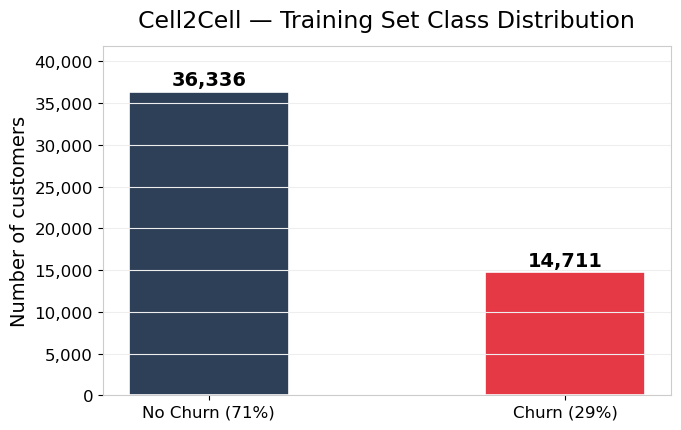

In [2]:
# Class distribution — why imbalance handling matters

churn_counts  = y.value_counts().sort_index()
churn_labels  = ["No Churn (71%)", "Churn (29%)"]
churn_colours = [C_BLUE, C_RED]

fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar(churn_labels, churn_counts.values,
              color=churn_colours, width=0.45, edgecolor="white", linewidth=1.2)
for bar, val in zip(bars, churn_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 300,
            f"{val:,}", ha="center", va="bottom", fontsize=14, fontweight="bold")
ax.set_title("Cell2Cell — Training Set Class Distribution", pad=14)
ax.set_ylabel("Number of customers")
ax.set_ylim(0, churn_counts.max() * 1.15)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.grid(axis="x", visible=False)
plt.tight_layout()
plt.show()


---
## RQ2 — Class Imbalance Handling

> *"How do different class imbalance handling techniques affect the ability of models to correctly identify churning customers?"*

Without correction, Logistic Regression identified just **3.3% of all churners** — 96 out of 2,942.
Four strategies were tested: **No Handling · Class Weighting · SMOTE · Random Under-Sampling**.


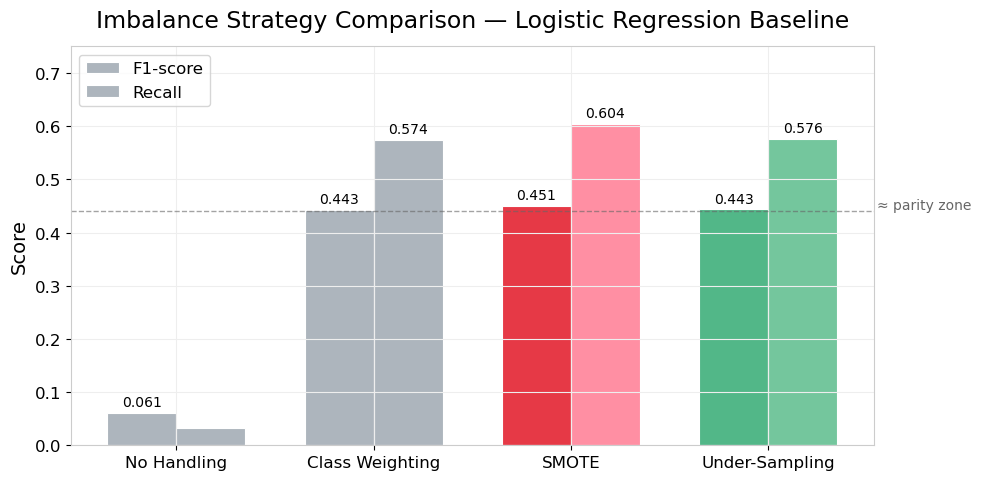

In [3]:
# RQ2 — Four strategies on Logistic Regression baseline

strategies = imb_lr["Strategy"].tolist()
x = np.arange(len(strategies))
w = 0.35
colours_f1  = [C_GREY, C_GREY, C_RED, C_GREEN]
colours_rec = [C_GREY, C_GREY, "#ff8fa3", "#74c69d"]

fig, ax = plt.subplots(figsize=(10, 5))
b1 = ax.bar(x - w/2, imb_lr["F1"],     width=w, color=colours_f1,  label="F1-score",
            edgecolor="white", linewidth=0.8)
b2 = ax.bar(x + w/2, imb_lr["Recall"], width=w, color=colours_rec, label="Recall",
            edgecolor="white", linewidth=0.8)

for bar in list(b1) + list(b2):
    h = bar.get_height()
    if h > 0.05:
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.007,
                f"{h:.3f}", ha="center", va="bottom", fontsize=10)

ax.set_xticks(x)
ax.set_xticklabels(strategies, fontsize=12)
ax.set_ylabel("Score")
ax.set_ylim(0, 0.75)
ax.set_title("Imbalance Strategy Comparison — Logistic Regression Baseline", pad=14)
ax.legend(loc="upper left")
ax.axhline(0.44, color="#666", linestyle="--", linewidth=1, alpha=0.6)
ax.text(3.55, 0.445, "≈ parity zone", fontsize=10, color="#666")
plt.tight_layout()
plt.show()


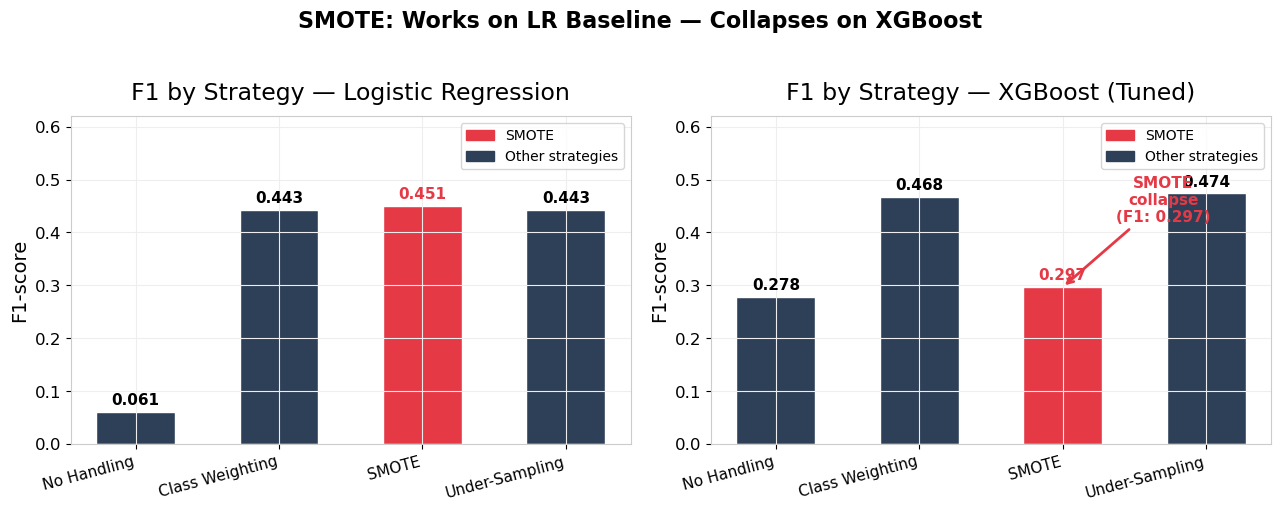

In [4]:
# RQ2 — SMOTE collapses on XGBoost: why technique selection must be validated

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=False)
strategies = imb_lr["Strategy"].tolist()
x = np.arange(len(strategies))
smote_idx = 2

def bar_colours(strategies, highlight_idx, hi_col, base_col):
    return [hi_col if i == highlight_idx else base_col for i in range(len(strategies))]

for ax, (model_name, df) in zip(axes, [("Logistic Regression", imb_lr),
                                         ("XGBoost (Tuned)", imb_xgb)]):
    cols = bar_colours(strategies, smote_idx, C_RED, C_BLUE)
    bars = ax.bar(x, df["F1"], color=cols, width=0.55, edgecolor="white", linewidth=1)
    for bar, val in zip(bars, df["F1"]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.008,
                f"{val:.3f}", ha="center", va="bottom",
                fontsize=11, fontweight="bold",
                color=C_RED if bar.get_facecolor() == plt.matplotlib.colors.to_rgba(C_RED) else "black")
    ax.set_xticks(x)
    ax.set_xticklabels(strategies, rotation=15, ha="right", fontsize=11)
    ax.set_ylabel("F1-score")
    ax.set_ylim(0, 0.62)
    ax.set_title(f"F1 by Strategy — {model_name}", pad=12)
    smote_patch = mpatches.Patch(color=C_RED,  label="SMOTE")
    base_patch  = mpatches.Patch(color=C_BLUE, label="Other strategies")
    ax.legend(handles=[smote_patch, base_patch], fontsize=10)

axes[1].annotate("SMOTE\ncollapse\n(F1: 0.297)",
                  xy=(smote_idx, 0.2967), xytext=(smote_idx + 0.7, 0.42),
                  arrowprops=dict(arrowstyle="->", color=C_RED, lw=2),
                  fontsize=11, color=C_RED, fontweight="bold", ha="center")

fig.suptitle("SMOTE: Works on LR Baseline — Collapses on XGBoost", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


---
### RQ2 — Findings

- **All three correction techniques** dramatically outperformed no handling (recall: 0.03 → 0.57+), confirming imbalance correction is essential for this task
- **SMOTE was rejected** despite a marginal F1 advantage on the LR baseline: it generates fractional values on binary one-hot encoded features, producing unrealistic synthetic customers — and when validated on XGBoost its F1 collapsed from 0.4507 → **0.2967**, below even the unhandled baseline
- **Random under-sampling** was selected: best F1 (0.4742) and recall (0.6254) on XGBoost, uses only real customer records, and reduced training time by 42%


---
## RQ1 — Neural Networks vs Traditional ML

> *"To what extent do neural network models compare to traditional ML in predicting customer churn, and how does hyperparameter optimisation influence their relative performance?"*

Seven models evaluated — from Logistic Regression through to a tuned Multi-Layer Perceptron —
all on **identical held-out test data** (10,210 records), all with equivalent hyperparameter tuning.


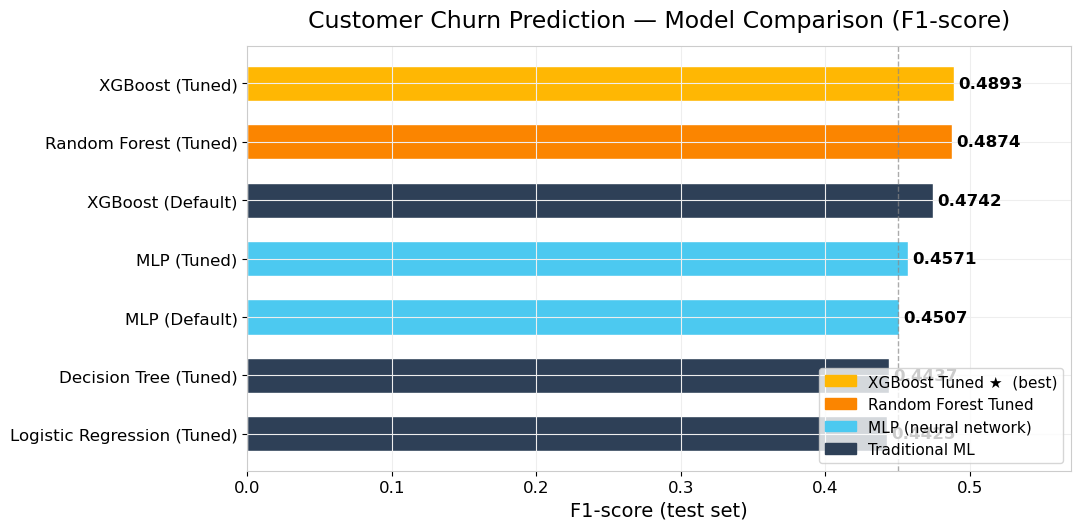

In [5]:
# RQ1 — Full model comparison: F1-score across all seven models

order = [
    "Logistic Regression (Tuned)",
    "Decision Tree (Tuned)",
    "MLP (Default)",
    "MLP (Tuned)",
    "XGBoost (Default)",
    "Random Forest (Tuned)",
    "XGBoost (Tuned)",
]
_base = Path("..").resolve()
nb04 = pd.read_csv(_base / "data/processed/notebook04_results.csv", index_col=0)

# Build unified table (use tuned where available, default otherwise)
all_rows = {}
for idx, row in full_results.iterrows():
    all_rows[idx] = row["F1-score"]
mlp_default_f1 = 0.4507
all_rows["MLP (Default)"] = mlp_default_f1
scores = pd.Series(all_rows).reindex(order)

colours = []
for name in order:
    if name == "XGBoost (Tuned)":    colours.append(C_GOLD)
    elif name == "Random Forest (Tuned)": colours.append(C_ORANGE)
    elif "MLP" in name:              colours.append("#4CC9F0")
    else:                            colours.append(C_BLUE)

fig, ax = plt.subplots(figsize=(11, 5.5))
bars = ax.barh(order, scores.values, color=colours,
               height=0.6, edgecolor="white", linewidth=1)
for bar, val in zip(bars, scores.values):
    ax.text(val + 0.003, bar.get_y() + bar.get_height()/2,
            f"{val:.4f}", va="center", fontsize=12, fontweight="bold")
ax.set_xlabel("F1-score (test set)")
ax.set_xlim(0, 0.57)
ax.set_title("Customer Churn Prediction — Model Comparison (F1-score)", pad=14)
ax.axvline(0.45, color="#888", linestyle="--", linewidth=1, alpha=0.7)

legend_patches = [
    mpatches.Patch(color=C_GOLD,   label="XGBoost Tuned ★  (best)"),
    mpatches.Patch(color=C_ORANGE, label="Random Forest Tuned"),
    mpatches.Patch(color="#4CC9F0",label="MLP (neural network)"),
    mpatches.Patch(color=C_BLUE,   label="Traditional ML"),
]
ax.legend(handles=legend_patches, loc="lower right", fontsize=11)
plt.tight_layout()
plt.show()


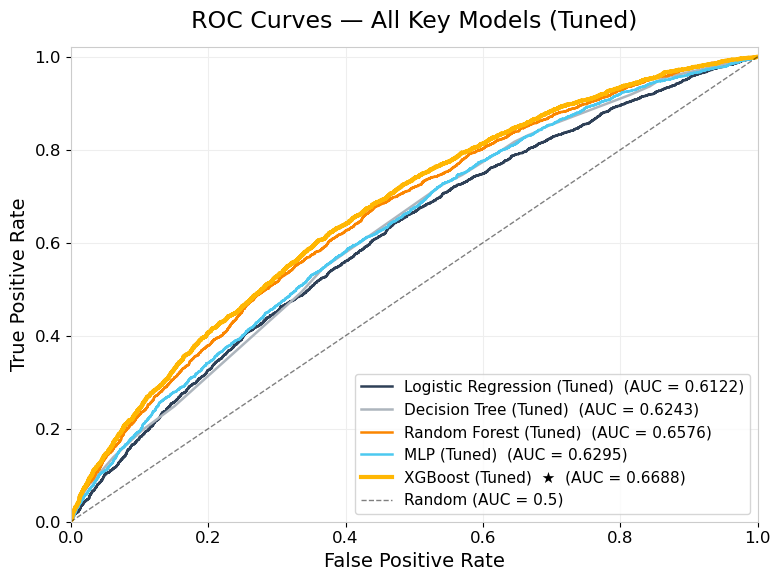

In [6]:
# RQ1 — ROC curves: separability across all key models

roc_colours = {
    "Logistic Regression": C_BLUE,
    "Decision Tree":       C_GREY,
    "Random Forest":       C_ORANGE,
    "MLP":                 "#4CC9F0",
    "XGBoost":             C_GOLD,
}
roc_labels = {
    "Logistic Regression": "Logistic Regression (Tuned)",
    "Decision Tree":       "Decision Tree (Tuned)",
    "Random Forest":       "Random Forest (Tuned)",
    "MLP":                 "MLP (Tuned)",
    "XGBoost":             "XGBoost (Tuned)  ★",
}

fig, ax = plt.subplots(figsize=(8, 6))
for name, (fpr, tpr, roc_auc) in roc_data.items():
    lw = 3 if name == "XGBoost" else 1.8
    ax.plot(fpr, tpr, color=roc_colours[name], lw=lw,
            label=f"{roc_labels[name]}  (AUC = {roc_auc:.4f})")
ax.plot([0,1],[0,1], "k--", lw=1, alpha=0.5, label="Random (AUC = 0.5)")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves — All Key Models (Tuned)", pad=14)
ax.legend(loc="lower right", fontsize=11)
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
plt.tight_layout()
plt.show()


---
### RQ1 — Findings

- **XGBoost (Tuned)** is the best model: F1 **0.4893**, ROC-AUC **0.6688** — outperforming the tuned MLP (F1: 0.4571) despite both receiving equivalent hyperparameter optimisation
- **Hyperparameter tuning meaningfully improved the MLP**: recall rose from 0.5663 → **0.6264** (+177 churners correctly identified); the winning configuration used `logistic` activation over `relu` — sigmoid non-linearity fits better on binary tabular features
- **Consistent with Grinsztajn et al. (2022)**: gradient-boosted tree ensembles consistently outperform MLPs on structured tabular data; the MLP beats simple baselines (LR, DT) but cannot close the gap with XGBoost or Random Forest even after tuning


---
## RQ3 — Feature Importance & Churn Drivers

> *"Which customer features have the greatest influence on churn prediction, and what do they reveal about the drivers of customer churn?"*

SHAP (SHapley Additive exPlanations) applied to **XGBoost (Tuned)** on 1,000 stratified test customers.
Each value measures how much a feature **pushed a prediction towards or away from churn**.


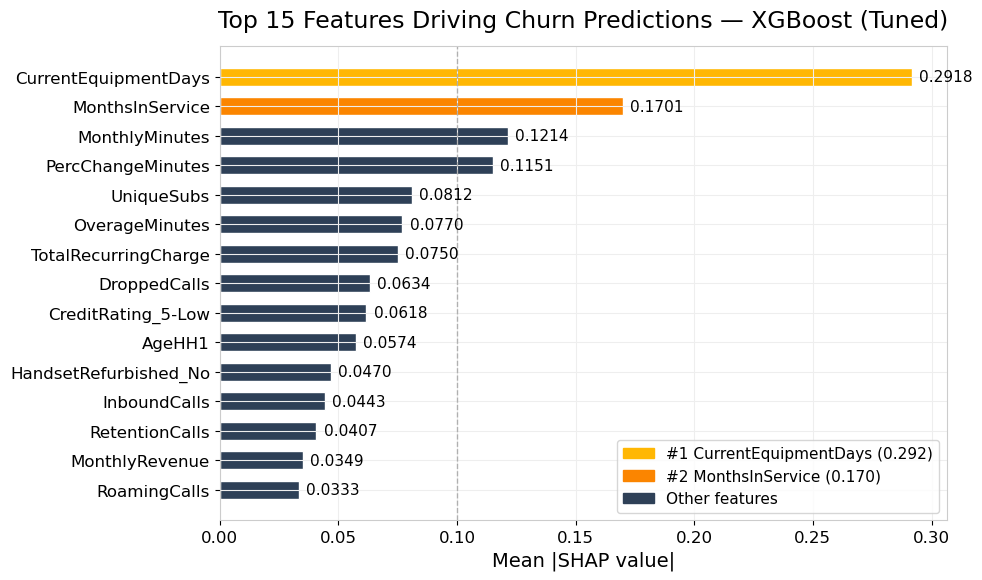

In [7]:
# RQ3 — Top 15 churn drivers (mean absolute SHAP value)

top15 = mean_shap.head(15)

fig, ax = plt.subplots(figsize=(10, 6))
colours_shap = [C_GOLD if i == 0 else C_ORANGE if i == 1 else C_BLUE
                for i in range(len(top15))]
bars = ax.barh(top15.index[::-1], top15.values[::-1],
               color=colours_shap[::-1], height=0.6, edgecolor="white")
for bar, val in zip(bars, top15.values[::-1]):
    ax.text(val + 0.003, bar.get_y() + bar.get_height()/2,
            f"{val:.4f}", va="center", fontsize=11)
ax.set_xlabel("Mean |SHAP value|")
ax.set_title("Top 15 Features Driving Churn Predictions — XGBoost (Tuned)", pad=14)
ax.axvline(0.1, color="#888", linestyle="--", linewidth=1, alpha=0.6)

legend_patches = [
    mpatches.Patch(color=C_GOLD,   label="#1 CurrentEquipmentDays (0.292)"),
    mpatches.Patch(color=C_ORANGE, label="#2 MonthsInService (0.170)"),
    mpatches.Patch(color=C_BLUE,   label="Other features"),
]
ax.legend(handles=legend_patches, loc="lower right", fontsize=11)
plt.tight_layout()
plt.show()


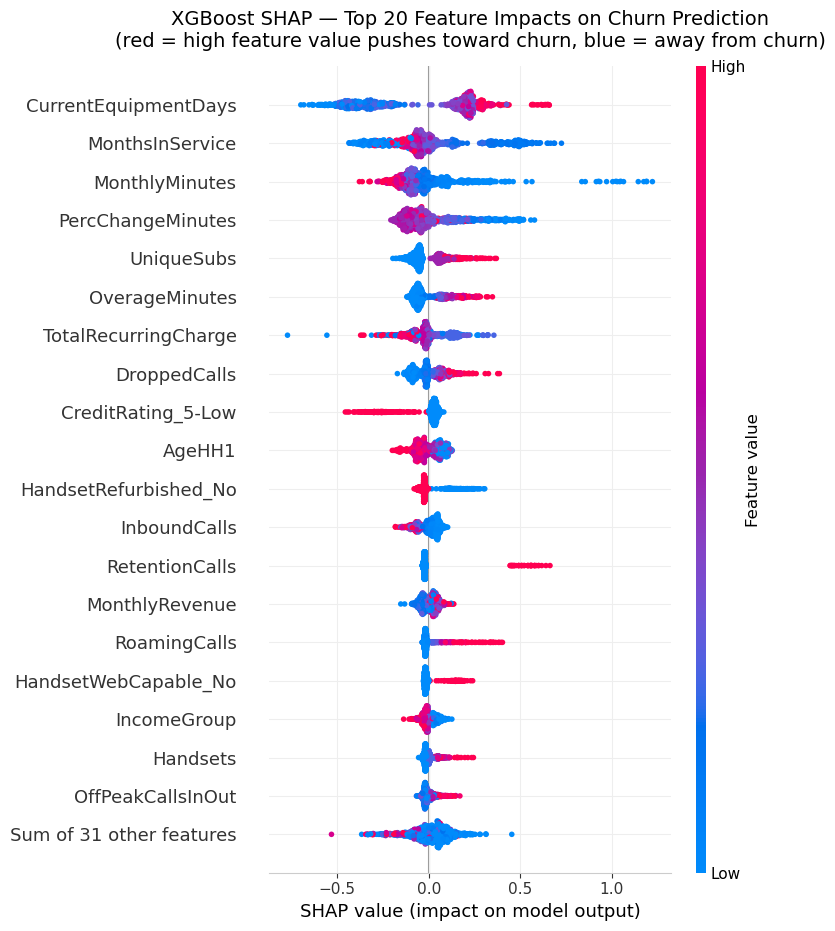

In [8]:
# RQ3 — SHAP beeswarm: direction and magnitude for every test customer

plt.figure(figsize=(11, 7))
shap.plots.beeswarm(shap_exp, max_display=20, show=False)
plt.title("XGBoost SHAP — Top 20 Feature Impacts on Churn Prediction\n"
          "(red = high feature value pushes toward churn, blue = away from churn)",
          pad=14, fontsize=14)
plt.tight_layout()
plt.show()


---
### RQ3 — Findings

- **Equipment age dominates**: `CurrentEquipmentDays` (mean |SHAP| = **0.2918**) is nearly **twice** as influential as any other feature — customers with ageing devices are actively seeking an upgrade, and switching provider is how they get it
- **First year = highest risk**: `MonthsInService` (#2, SHAP = 0.1701) confirms that **newer customers churn significantly more**; the first year of service is the critical retention window
- **Usage and billing form a coherent cluster**: `MonthlyMinutes` · `PercChangeMinutes` · `OverageMinutes` · `TotalRecurringCharge` consistently appear — both unusually high *and* low usage flag at-risk customers, suggesting two distinct at-risk segments
- **Business priority**: target customers with equipment >2 years old → customers in Year 1 → customers with high overage or recurring charges → customers experiencing dropped calls


---
## Final Model Validation

Cross-validation confirms the XGBoost (Tuned) results are **stable across different data splits**
and were not the product of a favourable 80/20 partition.


In [9]:
# Final validation — 5-fold CV vs held-out test set

cv_test = pd.DataFrame({
    "Metric":      ["Precision", "Recall", "F1-score", "ROC-AUC"],
    "Test Set":    [0.3887, 0.6601, 0.4893, 0.6688],
    "5-Fold CV":   ["0.3942 ± 0.005", "0.6630 ± 0.011", "0.4944 ± 0.006", "0.6747 ± 0.006"],
}).set_index("Metric")

styled = cv_test.style\
    .set_caption("XGBoost (Tuned) — Test Set vs 5-Fold Cross-Validation")\
    .set_table_styles([
        {"selector": "caption",
         "props": [("font-size", "15px"), ("font-weight", "bold"), ("padding-bottom", "8px")]},
        {"selector": "th",
         "props": [("background-color", "#2E4057"), ("color", "white"),
                   ("font-size", "13px"), ("padding", "8px 16px")]},
        {"selector": "td",
         "props": [("font-size", "13px"), ("padding", "8px 16px"), ("text-align", "center")]},
        {"selector": "tr:hover td",
         "props": [("background-color", "#f0f4ff")]},
    ])\
    .highlight_max(axis=0, props="background-color: #d4edda; font-weight: bold;")

from IPython.display import display
display(styled)
print()
print("✓  CV mean F1 (0.4944) closely matches test F1 (0.4893) — no overfitting to a single split.")
print("✓  CV std deviation ± 0.006 confirms the model is stable across different data partitions.")


,Test Set,5-Fold CV
Metric,,
Precision,0.388700,0.3942 ± 0.005
Recall,0.660100,0.6630 ± 0.011
F1-score,0.489300,0.4944 ± 0.006
ROC-AUC,0.668800,0.6747 ± 0.006



✓  CV mean F1 (0.4944) closely matches test F1 (0.4893) — no overfitting to a single split.
✓  CV std deviation ± 0.006 confirms the model is stable across different data partitions.


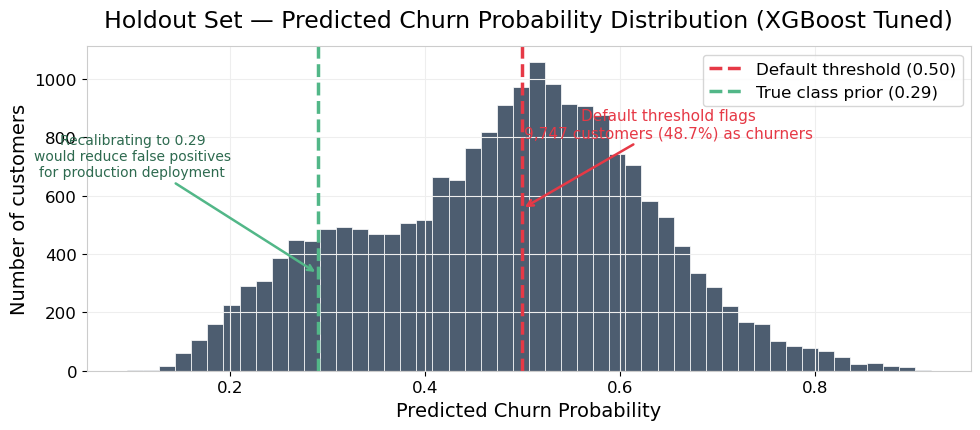

In [10]:
# Holdout set — predicted churn probability distribution (20,000 unseen customers)

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.hist(hold_probs, bins=50, color=C_BLUE, edgecolor="white", linewidth=0.6, alpha=0.85)
ax.axvline(0.5, color=C_RED,  linestyle="--", linewidth=2.5, label="Default threshold (0.50)")
ax.axvline(0.29, color=C_GREEN, linestyle="--", linewidth=2.5, label="True class prior (0.29)")
ax.set_xlabel("Predicted Churn Probability")
ax.set_ylabel("Number of customers")
ax.set_title("Holdout Set — Predicted Churn Probability Distribution (XGBoost Tuned)", pad=14)
ax.legend(fontsize=12)

n_pred   = (hold_probs >= 0.5).sum()
pct_pred = n_pred / len(hold_probs) * 100
ax.annotate(f"Default threshold flags\n{n_pred:,} customers ({pct_pred:.1f}%) as churners",
             xy=(0.5, ax.get_ylim()[1]*0.5),
             xytext=(0.65, ax.get_ylim()[1]*0.72),
             arrowprops=dict(arrowstyle="->", color=C_RED, lw=1.8),
             fontsize=11, color=C_RED, ha="center")
ax.annotate("Recalibrating to 0.29\nwould reduce false positives\nfor production deployment",
             xy=(0.29, ax.get_ylim()[1]*0.3),
             xytext=(0.10, ax.get_ylim()[1]*0.6),
             arrowprops=dict(arrowstyle="->", color=C_GREEN, lw=1.8),
             fontsize=10, color="#2d6a4f", ha="center")
plt.tight_layout()
plt.show()


---
## Summary

**RQ1 —** XGBoost (Tuned) is the best model with F1 = **0.4893** and ROC-AUC = **0.6688**, outperforming the tuned MLP (F1 = 0.4571) despite equivalent optimisation; hyperparameter tuning improved the MLP's recall by +0.060 (+177 additional churners identified) but was insufficient to close the gap with gradient-boosted tree ensembles — consistent with Grinsztajn et al. (2022).

**RQ2 —** All three imbalance correction strategies recovered recall from a catastrophic 3.3% to above 57%; random under-sampling was selected as the most appropriate technique, achieving the best F1 and recall on XGBoost (F1 = **0.4742**, recall = **0.6254**) whilst SMOTE — which appeared strongest on the LR baseline — collapsed to F1 = 0.2967 on XGBoost due to its incompatibility with binary one-hot encoded features, demonstrating that imbalance technique selection must be validated on the final model.

**RQ3 —** SHAP analysis identified `CurrentEquipmentDays` (|SHAP| = **0.2918**) and `MonthsInService` (0.1701) as the two dominant churn drivers, nearly double the influence of any usage or billing feature; the practical implication is that retention efforts should prioritise customers with ageing equipment and those in their first year of service before addressing billing friction signals.

---
*Cell2Cell dataset · 51,047 records · XGBoost Tuned · 5-fold CV F1 = 0.4944 ± 0.006*
